In [21]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [22]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
from plot_params import *
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import json
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap



In [23]:
# Load CSV generated by _plot_single_sweep and reproduce the figure.
csv_path = r".\tree_data.csv"

df = pd.read_csv(csv_path)

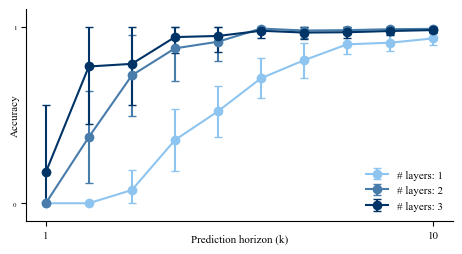

In [27]:
fig, ax1 = plt.subplots(figsize=(FIG_WIDTH, FIG_WIDTH/2))
sweep_vals = df["sweep_value"].unique()
cmap = LinearSegmentedColormap.from_list(
    "light_to_dark_blue",
    ["#8ec5f0", "#003366"]
)
norm = mcolors.Normalize(vmin=sweep_vals[0], vmax=sweep_vals[-1])
for sweep_value in sweep_vals:
    sub = df[df["sweep_value"] == sweep_value].sort_values("k")
    k_vals = sub["k"].to_numpy(dtype=float)

    test_acc_yerr = np.vstack(
        [
            sub["test_accuracy_yerr_lower"].to_numpy(dtype=float),
            sub["test_accuracy_yerr_upper"].to_numpy(dtype=float),
        ]
    )

    label = f"# layers: {int(sweep_value)}"

    ax1.errorbar(
        k_vals,
        sub["test_accuracy_mean"].to_numpy(dtype=float),
        yerr=test_acc_yerr,
        marker="o",
        capsize=3,
        label=label,
        color=cmap(norm(sweep_value)),
    )
ax1.set_ylim(-0.1, 1.1)

ax1.set_ylabel("Accuracy", labelpad=-5)
ax1.set_xlabel("Prediction horizon (k)", labelpad=-5)
ax1.set_yticks([0, 1])
ax1.set_xticks([k_vals[0], k_vals[-1]])
ax1.legend()

fig.savefig(r'./final_results/figures/fig_tree.png', dpi=300, bbox_inches='tight')